In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CareerRecommenderDataset.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTotal unique careers:", df['Career_Options'].nunique())
print("\nCareer distribution:")
print(df['Career_Options'].value_counts())

Shape: (3536, 61)

Columns:
 ['Drawing', 'Dancing', 'Singing', 'Sports', 'Video_Game', 'Acting', 'Travelling', 'Gardening', 'Animals', 'Photography', 'Teaching', 'Exercise', 'Coding', 'Electricity_Components', 'Mechanic_Parts', 'Computer_Parts', 'Researching', 'Architecture', 'Historic_Collection', 'Botany', 'Zoology', 'Physics', 'Accounting', 'Economics', 'Sociology', 'Geography', 'Psycology', 'History', 'Science', 'Bussiness_Education', 'Chemistry', 'Mathematics', 'Biology', 'Makeup', 'Designing', 'Content_Writing', 'Crafting', 'Literature', 'Reading', 'Cartooning', 'Debating', 'Asrtology', 'Hindi', 'French', 'English', 'Urdu', 'Other Language', 'Solving_Puzzles', 'Gymnastics', 'Yoga', 'Engeeniering', 'Doctor', 'Pharmisist', 'Cycling', 'Knitting', 'Director', 'Journalism', 'Bussiness', 'Listening_Music', 'Courses', 'Career_Options']

First few rows:
  Drawing Dancing Singing Sports Video_Game Acting Travelling Gardening  \
0      No      No      No     No         No     No         No

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# define feature columns (everything except Courses and Career_Options)
feature_cols = [col for col in df.columns if col not in ['Courses', 'Career_Options']]

# convert Yes/No to 1/0
for col in feature_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

X = df[feature_cols].values

# we predict Career_Options (the actual job roles, not the degree)
le = LabelEncoder()
y = le.fit_transform(df["Career_Options"])

# make sure every class has at least 2 samples (needed for stratified split)
from collections import Counter
counts = Counter(y)
valid_mask = np.array([counts[label] >= 2 for label in y])
X, y = X[valid_mask], y[valid_mask]

# also keep a courses mapping for later use in recommendations
courses_map = df[valid_mask][['Career_Options', 'Courses']].drop_duplicates()
courses_map = dict(zip(courses_map['Career_Options'], courses_map['Courses']))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Number of career classes: {len(le.classes_)}")
print(f"Sample label: {le.inverse_transform([y_train[0]])}")

Train size: 2820 | Test size: 706
Number of career classes: 45
Sample label: ['Economist, Financial Analyst, Policy Analyst']


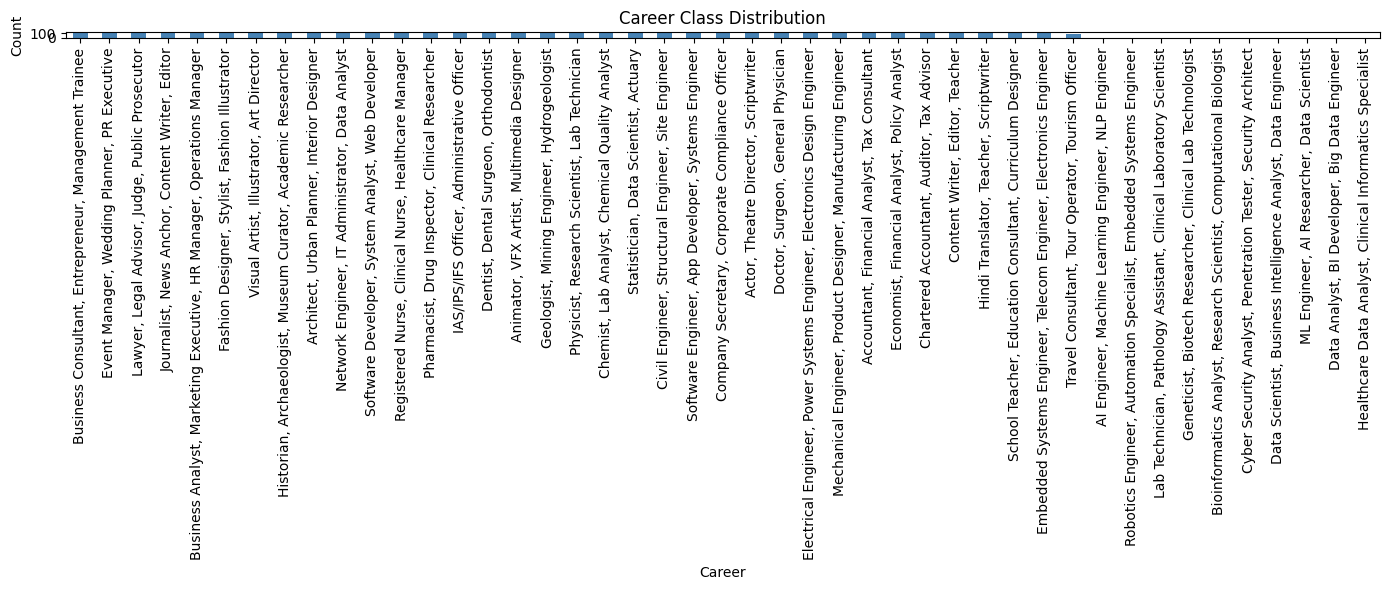

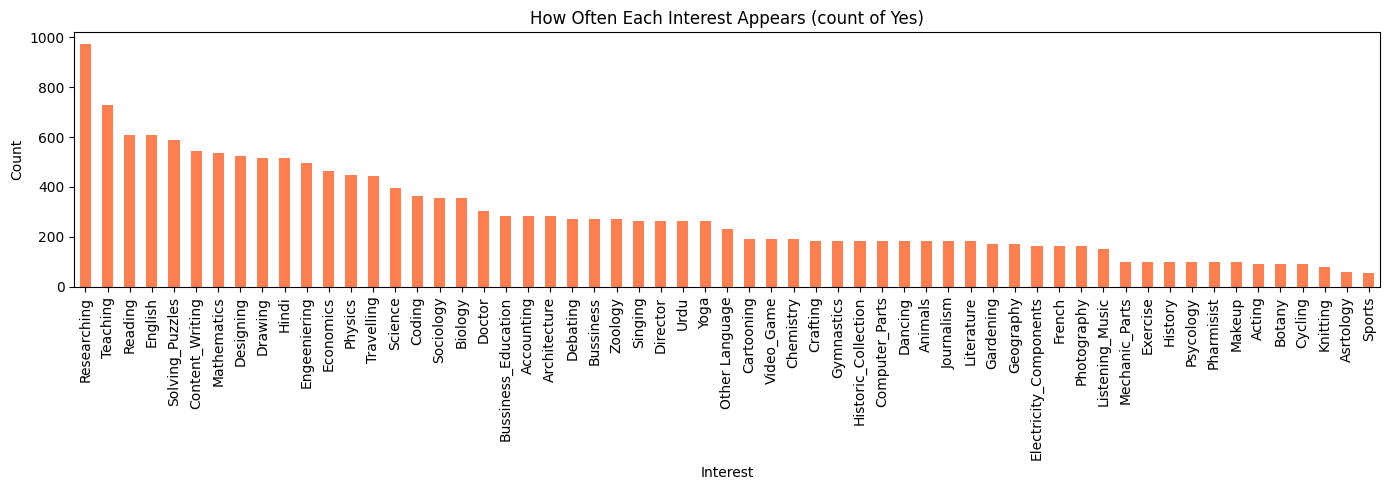

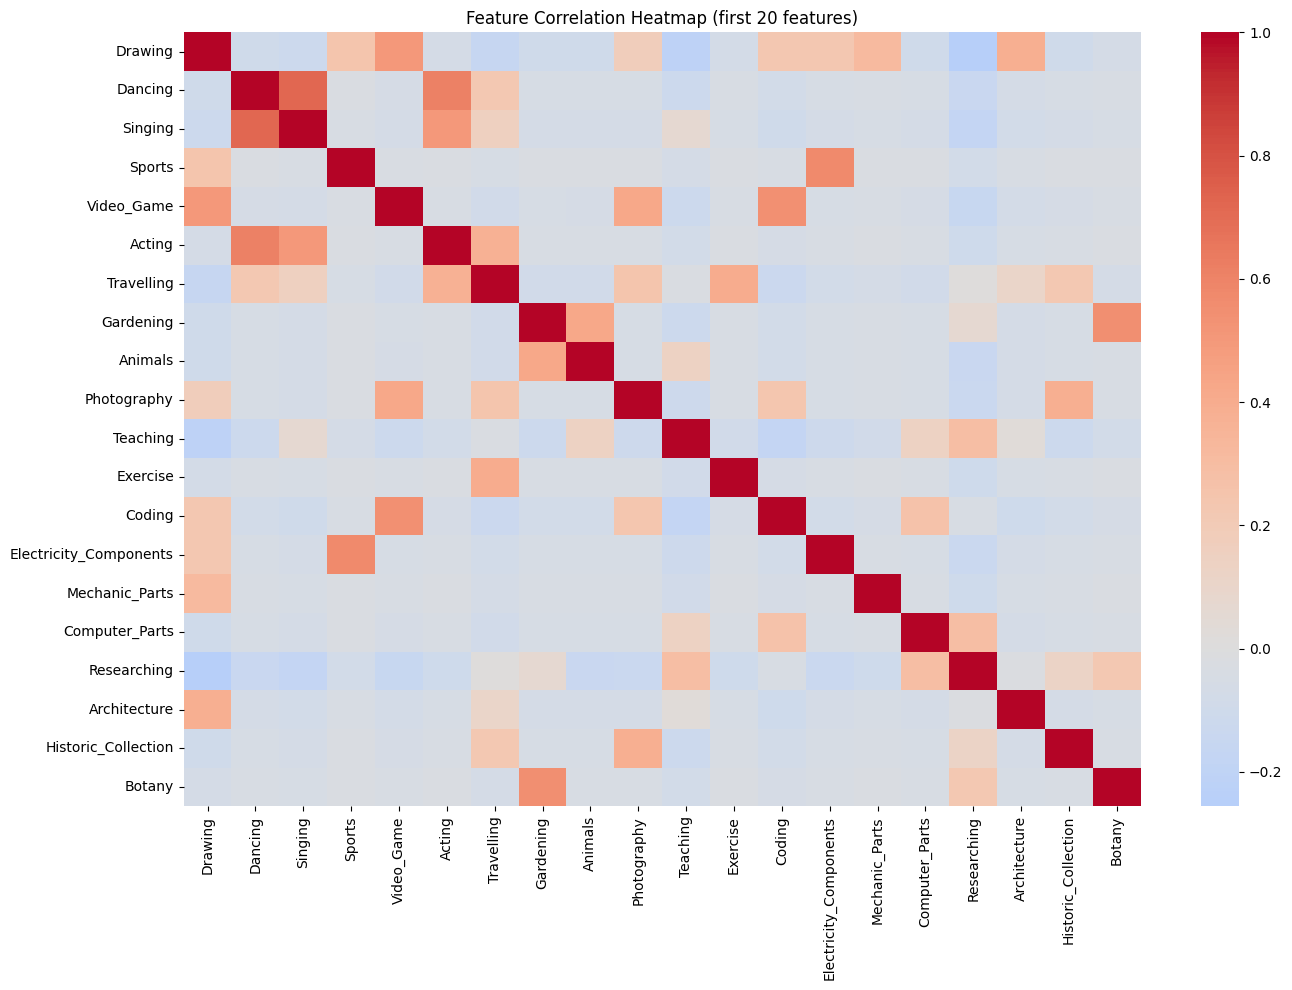

In [3]:
# career class distribution
plt.figure(figsize=(14, 6))
df['Career_Options'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Career Class Distribution")
plt.xlabel("Career")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

# how often each interest/feature appears across all users
feature_counts = pd.Series(X.sum(axis=0), index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(14, 5))
feature_counts.plot(kind='bar', color='coral')
plt.title("How Often Each Interest Appears (count of Yes)")
plt.xlabel("Interest")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("feature_counts.png")
plt.show()

# correlation heatmap for first 20 features
X_df = pd.DataFrame(X, columns=feature_cols)
plt.figure(figsize=(14, 10))
sns.heatmap(X_df.iloc[:, :20].corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap (first 20 features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# random forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest trained!")

# SVM with RBF kernel
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_model.fit(X_train, y_train)
print("SVM trained!")

# logistic regression as a baseline
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train, y_train)
print("Logistic Regression trained!")

Random Forest trained!
SVM trained!
Logistic Regression trained!



=== Random Forest ===
Accuracy : 0.9972
F1 Score : 0.9972
                                                                          precision    recall  f1-score   support

                           Accountant, Financial Analyst, Tax Consultant       1.00      0.90      0.95        20
                                   Actor, Theatre Director, Scriptwriter       1.00      1.00      1.00        20
                               Animator, VFX Artist, Multimedia Designer       1.00      1.00      1.00        20
                             Architect, Urban Planner, Interior Designer       1.00      1.00      1.00        20
   Business Analyst, Marketing Executive, HR Manager, Operations Manager       1.00      1.00      1.00        20
                   Business Consultant, Entrepreneur, Management Trainee       0.92      1.00      0.96        23
                              Chartered Accountant, Auditor, Tax Advisor       1.00      1.00      1.00        20
                          Ch

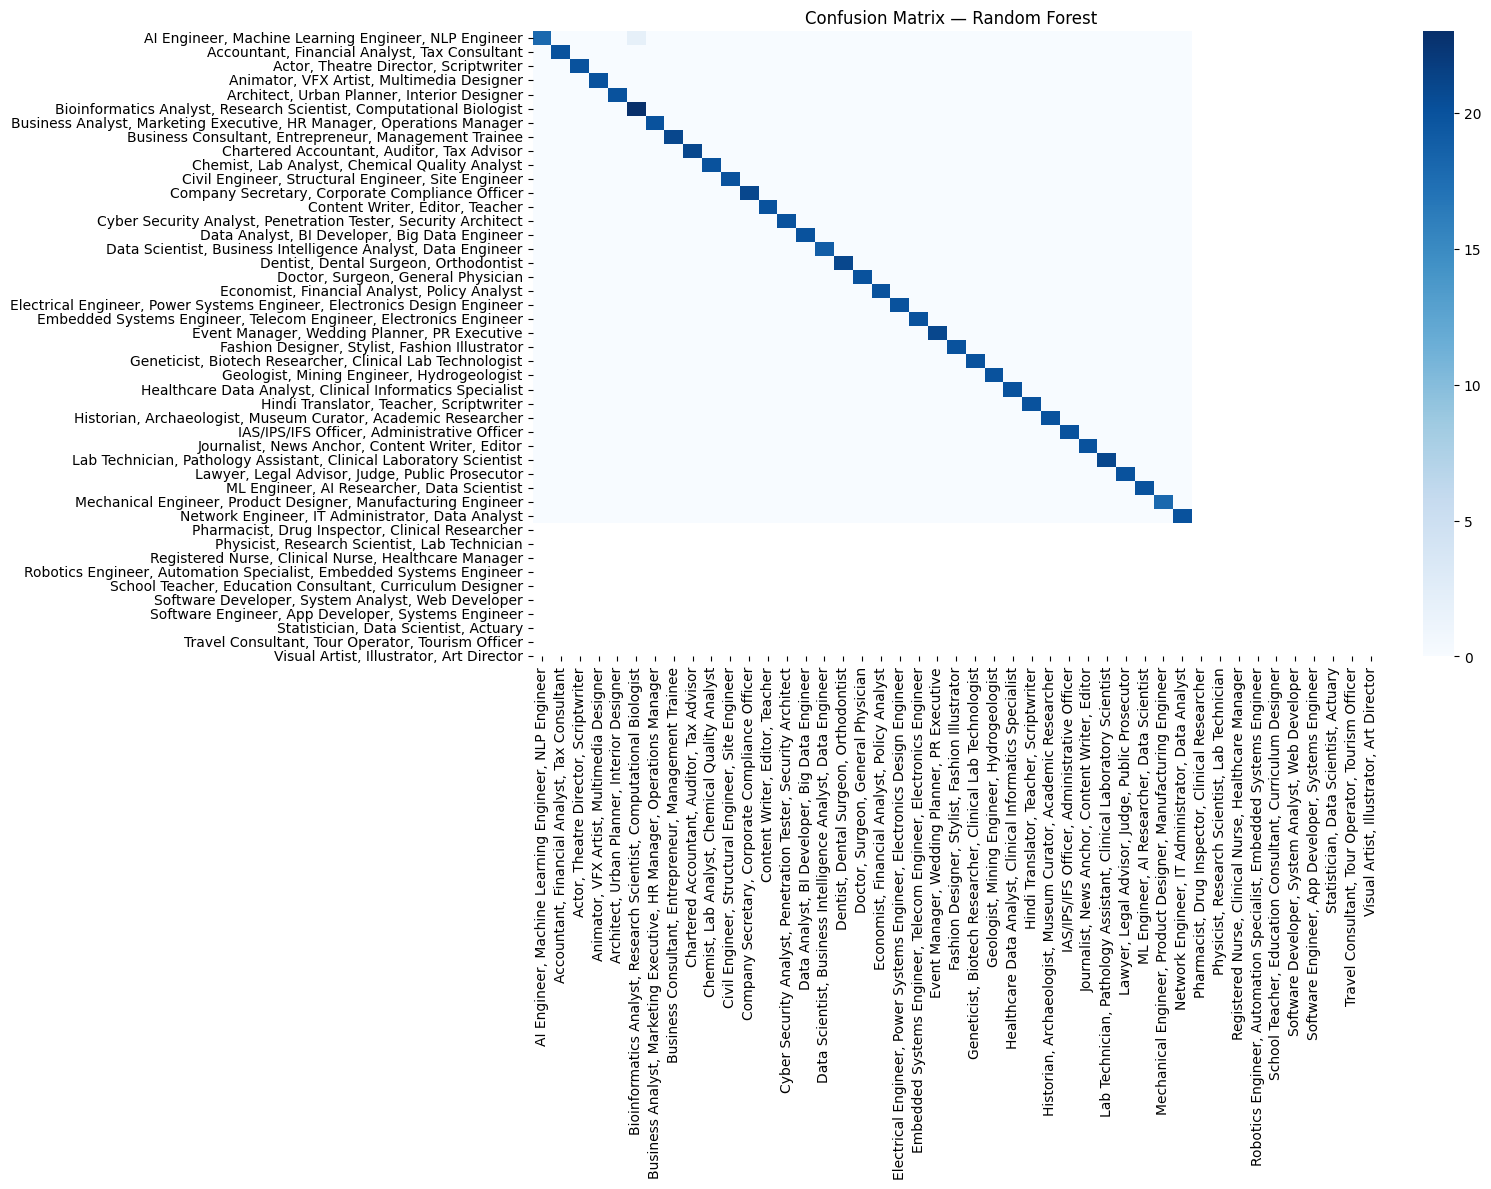

In [5]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    'Random Forest': rf_model,
    'SVM (RBF)': svm_model,
    'Logistic Regression': lr_model
}

results = {}
all_preds = {}

for name, model in models.items():
    preds = model.predict(X_test)
    all_preds[name] = preds
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': round(acc, 4), 'F1 (weighted)': round(f1, 4)}

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(classification_report(
        y_test,
        preds,
        target_names=le.inverse_transform(sorted(set(y_test)))
    ))

# summary table
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison Summary ---")
print(results_df)

# confusion matrix for the best model
best_model_name = results_df['Accuracy'].idxmax()
print(f"\nBest model: {best_model_name}")

best_preds = all_preds[best_model_name]
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV F1 score:", round(rf_search.best_score_, 4))

# compare tuned vs original
tuned_rf_model = rf_search.best_estimator_
tuned_preds = tuned_rf_model.predict(X_test)

print("\n--- Before vs After Tuning ---")
print(f"Original RF  — Accuracy: {accuracy_score(y_test, all_preds['Random Forest']):.4f} | F1: {f1_score(y_test, all_preds['Random Forest'], average='weighted'):.4f}")
print(f"Tuned RF     — Accuracy: {accuracy_score(y_test, tuned_preds):.4f} | F1: {f1_score(y_test, tuned_preds, average='weighted'):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV F1 score: 0.9971

--- Before vs After Tuning ---
Original RF  — Accuracy: 0.9972 | F1: 0.9972
Tuned RF     — Accuracy: 0.9972 | F1: 0.9972


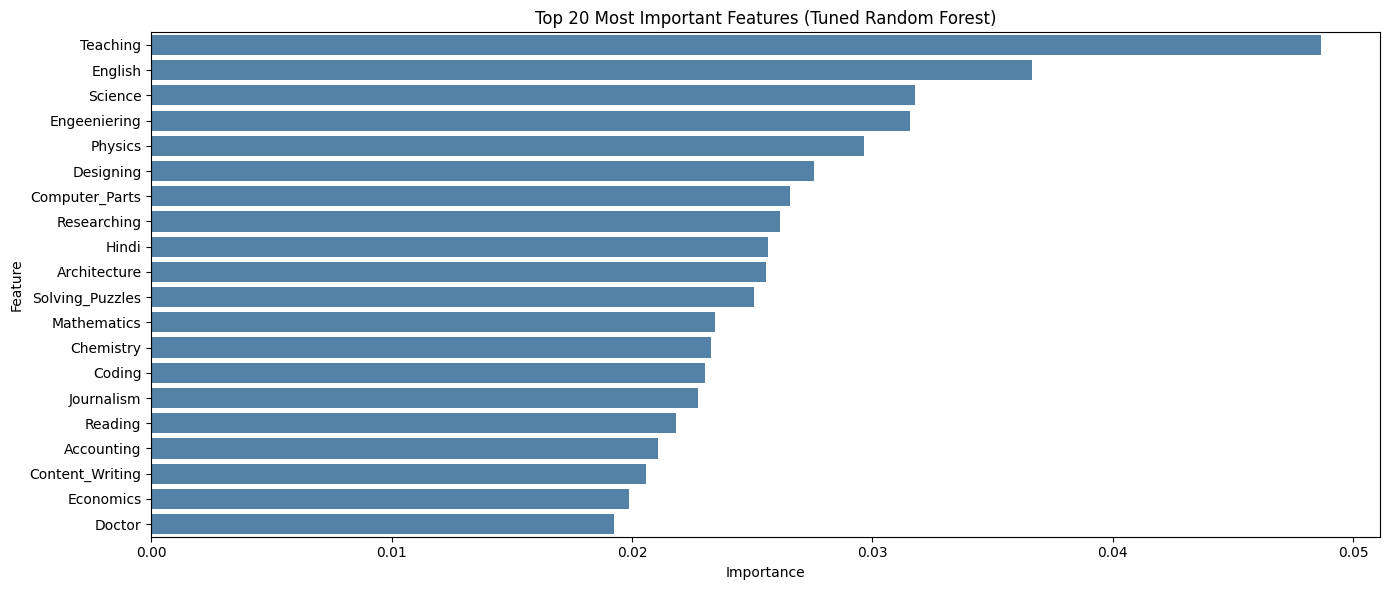


Top 10 most important interests:
       Feature  Importance
      Teaching    0.048688
       English    0.036650
       Science    0.031785
  Engeeniering    0.031583
       Physics    0.029651
     Designing    0.027559
Computer_Parts    0.026573
   Researching    0.026163
         Hindi    0.025644
  Architecture    0.025559


In [7]:
# show which interests matter most for career prediction
importances = tuned_rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', color='steelblue')
plt.title("Top 20 Most Important Features (Tuned Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print("\nTop 10 most important interests:")
print(importance_df.head(10).to_string(index=False))

In [8]:
import joblib
import json

# save the tuned model and everything needed at inference time
joblib.dump(tuned_rf_model, 'model.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(feature_cols, 'feature_names.pkl')
joblib.dump(courses_map, 'courses_map.pkl')

# save metadata so anyone loading the model knows what it expects
metadata = {
    'model_type': 'RandomForest (tuned)',
    'n_features': len(feature_cols),
    'n_classes': len(le.classes_),
    'target': 'Career_Options'
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved files:")
print("  model.pkl")
print("  label_encoder.pkl")
print("  feature_names.pkl")
print("  courses_map.pkl")
print("  model_metadata.json")

# quick reload check
test_load = joblib.load('model.pkl')
print("\nReload check passed:", type(test_load))

Saved files:
  model.pkl
  label_encoder.pkl
  feature_names.pkl
  courses_map.pkl
  model_metadata.json

Reload check passed: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [9]:
import joblib
import pandas as pd

# load everything
model = joblib.load('model.pkl')
le = joblib.load('label_encoder.pkl')
feature_cols = joblib.load('feature_names.pkl')
courses_map = joblib.load('courses_map.pkl')

job_postings = pd.read_csv('job_postings.csv')
job_skills = pd.read_csv('job_skills.csv')


def predict_career(user_interests: dict):
    """
    Pass in a dict of interests with 1 (yes) or 0 (no).
    Example: {'Coding': 1, 'Mathematics': 1, 'Drawing': 0}
    Any feature not mentioned defaults to 0.
    """

    # warn if user passes an unrecognized interest
    for key in user_interests:
        if key not in feature_cols:
            print(f"Warning: '{key}' is not recognized and will be ignored.")

    # build the input vector
    input_row = {col: 0 for col in feature_cols}
    for key, val in user_interests.items():
        if key in input_row:
            input_row[key] = val

    # use numpy array to avoid sklearn column name warning
    input_array = pd.DataFrame([input_row])[feature_cols].values

    # get top 3 predictions with confidence scores
    probs = model.predict_proba(input_array)[0]
    top3_indices = probs.argsort()[-3:][::-1]
    top3_careers = le.inverse_transform(top3_indices)
    top3_probs = probs[top3_indices]

    print("=" * 55)
    print("           TOP CAREER RECOMMENDATIONS")
    print("=" * 55)
    for i, (career, prob) in enumerate(zip(top3_careers, top3_probs), 1):
        recommended_course = courses_map.get(career, "N/A")
        print(f"\n#{i}: {career}")
        print(f"     Confidence     : {round(prob * 100, 2)}%")
        print(f"     Recommended Course: {recommended_course}")

    # job postings enrichment — search using all keywords from top career
    top_career = top3_careers[0]
    keywords = [k.strip().lower() for k in top_career.split(',')]

    matched_jobs = job_postings[
        job_postings['job_title'].str.lower().apply(
            lambda t: any(k in t for k in keywords)
        )
    ][['job_title', 'company', 'job_location', 'job_type']].head(5)

    print("\n" + "=" * 55)
    print(f"  RELATED JOB POSTINGS")
    print("=" * 55)
    if matched_jobs.empty:
        print("  No matching job postings found.")
    else:
        print(matched_jobs.to_string(index=False))

    # skills enrichment from job_skills dataset
    matched_skills = job_skills[
        job_skills['Title'].str.lower().str.contains(keywords[0], na=False)
    ][['Title', 'Minimum Qualifications']].head(3)

    print("\n" + "=" * 55)
    print(f"  SKILLS & QUALIFICATIONS NEEDED")
    print("=" * 55)
    if matched_skills.empty:
        print("  No matching skills data found.")
    else:
        for _, row in matched_skills.iterrows():
            print(f"\nRole        : {row['Title']}")
            print(f"Qualifications: {row['Minimum Qualifications'][:300]}...")

    return {
        'predictions': list(zip(top3_careers.tolist(), top3_probs.tolist())),
        'matched_jobs': matched_jobs.to_dict(orient='records'),
        'matched_skills': matched_skills.to_dict(orient='records')
    }


# test with a sample user
sample_user = {
    'Coding': 1,
    'Mathematics': 1,
    'Computer_Parts': 1,
    'Researching': 1,
    'Science': 1
}

result = predict_career(sample_user)

           TOP CAREER RECOMMENDATIONS

#1: Healthcare Data Analyst, Clinical Informatics Specialist
     Confidence     : 54.43%
     Recommended Course: N/A

#2: Lawyer, Legal Advisor, Judge, Public Prosecutor
     Confidence     : 23.5%
     Recommended Course: Integrated Law Course- BA + LL.B

#3: Lab Technician, Pathology Assistant, Clinical Laboratory Scientist
     Confidence     : 16.86%
     Recommended Course: N/A

  RELATED JOB POSTINGS
                                                               job_title                      company                     job_location job_type
                                               Healthcare Data Analyst I                 Health First               Brevard County, FL   Onsite
                                                 HealthCare Data Analyst               Sentara Health                     Richmond, VA   Onsite
                                                 Healthcare Data Analyst Strategic Staffing Solutions                